In [3]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 输入日志内容
log_text = """
Epoch 1/500, Train Loss: 8.7466, Validation Loss: 11.4060
Test Loss: 3.154140
Epoch 2/500, Train Loss: 8.6517, Validation Loss: 9.2949
Test Loss: 2.782209
Model saved!
Epoch 3/500, Train Loss: 8.3258, Validation Loss: 9.3533
Test Loss: 2.795642
Epoch 4/500, Train Loss: 8.0103, Validation Loss: 11.2468
Test Loss: 2.827605
Epoch 5/500, Train Loss: 7.5973, Validation Loss: 8.1178
Test Loss: 2.701663
Model saved!
Epoch 6/500, Train Loss: 6.5729, Validation Loss: 6.8485
Test Loss: 2.748938
Model saved!
Epoch 7/500, Train Loss: 5.6527, Validation Loss: 5.0247
Test Loss: 2.546161
Model saved!
Epoch 8/500, Train Loss: 4.7295, Validation Loss: 4.2935
Test Loss: 2.462012
Model saved!
Epoch 9/500, Train Loss: 3.9825, Validation Loss: 4.3419
Test Loss: 2.385098
Epoch 10/500, Train Loss: 3.3774, Validation Loss: 3.8629
Test Loss: 2.240925
Model saved!
Epoch 11/500, Train Loss: 2.9441, Validation Loss: 2.8010
Test Loss: 2.394023
Model saved!
Epoch 12/500, Train Loss: 2.8453, Validation Loss: 3.1349
Test Loss: 2.677026
Epoch 13/500, Train Loss: 2.8307, Validation Loss: 2.6740
Test Loss: 2.957150
Model saved!
Epoch 14/500, Train Loss: 2.7552, Validation Loss: 2.6605
Test Loss: 2.052634
Model saved!
Epoch 15/500, Train Loss: 2.5315, Validation Loss: 2.8671
Test Loss: 2.110981
Epoch 16/500, Train Loss: 2.5251, Validation Loss: 2.8459
Test Loss: 2.925652
Epoch 17/500, Train Loss: 2.4698, Validation Loss: 2.3185
Test Loss: 2.175678
Model saved!
Epoch 18/500, Train Loss: 2.4417, Validation Loss: 2.4517
Test Loss: 2.235631
Epoch 19/500, Train Loss: 2.3029, Validation Loss: 2.6246
Test Loss: 1.953756
Epoch 20/500, Train Loss: 2.2635, Validation Loss: 2.0848
Test Loss: 2.061360
Model saved!
Epoch 21/500, Train Loss: 2.2272, Validation Loss: 2.5230
Test Loss: 2.303394
Epoch 22/500, Train Loss: 2.2819, Validation Loss: 2.2357
Test Loss: 2.114560
Epoch 23/500, Train Loss: 2.2110, Validation Loss: 2.2991
Test Loss: 2.145402
Epoch 24/500, Train Loss: 2.2303, Validation Loss: 2.1388
Test Loss: 2.124188
Epoch 25/500, Train Loss: 2.1470, Validation Loss: 2.1632
Test Loss: 2.212175
Epoch 26/500, Train Loss: 2.1293, Validation Loss: 2.7406
Test Loss: 2.659696
Epoch 27/500, Train Loss: 2.0303, Validation Loss: 2.0703
Test Loss: 1.945622
Model saved!
Epoch 28/500, Train Loss: 1.9660, Validation Loss: 2.0655
Test Loss: 1.789693
Model saved!
Epoch 29/500, Train Loss: 1.9831, Validation Loss: 2.3500
Test Loss: 2.575660
Epoch 30/500, Train Loss: 2.0300, Validation Loss: 1.9050
Test Loss: 1.715128
Model saved!
Epoch 31/500, Train Loss: 1.9125, Validation Loss: 2.3350
Test Loss: 1.881240
Epoch 32/500, Train Loss: 1.8243, Validation Loss: 1.6997
Test Loss: 1.983456
Model saved!
Epoch 33/500, Train Loss: 1.8431, Validation Loss: 2.1616
Test Loss: 2.037153
Epoch 34/500, Train Loss: 1.7776, Validation Loss: 2.0261
Test Loss: 1.668912
Epoch 35/500, Train Loss: 1.7741, Validation Loss: 1.7781
Test Loss: 1.708956
Epoch 36/500, Train Loss: 1.6944, Validation Loss: 1.8474
Test Loss: 2.327412
Epoch 37/500, Train Loss: 1.6981, Validation Loss: 1.7455
Test Loss: 1.929318
Epoch 38/500, Train Loss: 1.6180, Validation Loss: 1.6631
Test Loss: 1.566567
Model saved!
Epoch 39/500, Train Loss: 1.7213, Validation Loss: 1.7878
Test Loss: 1.441655
Epoch 40/500, Train Loss: 1.6578, Validation Loss: 1.7542
Test Loss: 2.781716
Epoch 41/500, Train Loss: 1.6664, Validation Loss: 1.5996
Test Loss: 1.981232
Model saved!
Epoch 42/500, Train Loss: 1.5636, Validation Loss: 1.7638
Test Loss: 2.423614
Epoch 43/500, Train Loss: 1.5924, Validation Loss: 1.6758
Test Loss: 1.447033
Epoch 44/500, Train Loss: 1.5275, Validation Loss: 1.4478
Test Loss: 1.370217
Model saved!
Epoch 45/500, Train Loss: 1.6901, Validation Loss: 1.4507
Test Loss: 1.718810
Epoch 46/500, Train Loss: 1.5067, Validation Loss: 1.6017
Test Loss: 2.049684
Epoch 47/500, Train Loss: 1.4898, Validation Loss: 1.3698
Test Loss: 1.752674
Model saved!
Epoch 48/500, Train Loss: 1.5228, Validation Loss: 1.7947
Test Loss: 2.191713
Epoch 49/500, Train Loss: 1.4393, Validation Loss: 1.4438
Test Loss: 1.304278
Epoch 50/500, Train Loss: 1.5052, Validation Loss: 1.6612
Test Loss: 2.213436
Epoch 51/500, Train Loss: 1.4022, Validation Loss: 1.2907
Test Loss: 1.924333
Model saved!
Epoch 52/500, Train Loss: 1.4258, Validation Loss: 1.7921
Test Loss: 1.417921
Epoch 53/500, Train Loss: 1.3915, Validation Loss: 1.6045
Test Loss: 1.247350
Epoch 54/500, Train Loss: 1.3748, Validation Loss: 1.2730
Test Loss: 1.525131
Model saved!
Epoch 55/500, Train Loss: 1.3559, Validation Loss: 1.2863
Test Loss: 1.587569
Epoch 56/500, Train Loss: 1.3396, Validation Loss: 1.5324
Test Loss: 1.420393
Epoch 57/500, Train Loss: 1.4222, Validation Loss: 1.2777
Test Loss: 1.931716
Epoch 58/500, Train Loss: 1.3160, Validation Loss: 1.2352
Test Loss: 1.319002
Model saved!
Epoch 59/500, Train Loss: 1.3611, Validation Loss: 1.5252
Test Loss: 1.562701
Epoch 60/500, Train Loss: 1.2791, Validation Loss: 1.2393
Test Loss: 2.105651
Epoch 61/500, Train Loss: 1.3161, Validation Loss: 1.4683
Test Loss: 1.176165
Epoch 62/500, Train Loss: 1.3290, Validation Loss: 1.4123
Test Loss: 2.045441
Epoch 63/500, Train Loss: 1.2524, Validation Loss: 1.5689
Test Loss: 1.674149
Epoch 64/500, Train Loss: 1.2827, Validation Loss: 1.7543
Test Loss: 1.972751
Epoch 65/500, Train Loss: 1.2218, Validation Loss: 1.4607
Test Loss: 1.117262
Epoch 66/500, Train Loss: 1.2110, Validation Loss: 1.0873
Test Loss: 1.217058
Model saved!
Epoch 67/500, Train Loss: 1.2165, Validation Loss: 1.2130
Test Loss: 1.579249
Epoch 68/500, Train Loss: 1.1628, Validation Loss: 1.3874
Test Loss: 1.593524
Epoch 69/500, Train Loss: 1.1929, Validation Loss: 1.1685
Test Loss: 2.471218
Epoch 70/500, Train Loss: 1.2232, Validation Loss: 1.1384
Test Loss: 1.202398
Epoch 71/500, Train Loss: 1.2209, Validation Loss: 1.3175
Test Loss: 1.324474
Epoch 72/500, Train Loss: 1.1409, Validation Loss: 1.0727
Test Loss: 1.152680
Model saved!
Epoch 73/500, Train Loss: 1.1657, Validation Loss: 1.5996
Test Loss: 1.296313
Epoch 74/500, Train Loss: 1.1450, Validation Loss: 1.1813
Test Loss: 1.418564
Epoch 75/500, Train Loss: 1.1448, Validation Loss: 1.4702
Test Loss: 1.273387
Epoch 76/500, Train Loss: 1.1517, Validation Loss: 1.1821
Test Loss: 0.971385
Model saved!
Epoch 77/500, Train Loss: 1.1137, Validation Loss: 1.0929
Test Loss: 1.079700
Epoch 78/500, Train Loss: 1.1733, Validation Loss: 1.3807
Test Loss: 1.289587
Epoch 79/500, Train Loss: 1.1387, Validation Loss: 1.1032
Test Loss: 1.327500
Epoch 80/500, Train Loss: 1.1483, Validation Loss: 1.3471
Test Loss: 2.451732
Epoch 81/500, Train Loss: 1.1423, Validation Loss: 0.9594
Test Loss: 1.340626
Model saved!
Epoch 82/500, Train Loss: 1.0961, Validation Loss: 1.2132
Test Loss: 2.083943
Epoch 83/500, Train Loss: 1.0817, Validation Loss: 1.2661
Test Loss: 1.050027
Epoch 84/500, Train Loss: 1.1292, Validation Loss: 1.1852
Test Loss: 1.223922
Epoch 85/500, Train Loss: 1.0763, Validation Loss: 1.1904
Test Loss: 0.928066
Model saved!
Epoch 86/500, Train Loss: 1.1472, Validation Loss: 0.9935
Test Loss: 1.323519
Epoch 87/500, Train Loss: 1.1075, Validation Loss: 0.9774
Test Loss: 0.981283
Epoch 88/500, Train Loss: 1.0771, Validation Loss: 1.6627
Test Loss: 1.554346
Epoch 89/500, Train Loss: 1.0697, Validation Loss: 1.1785
Test Loss: 1.573552
Epoch 90/500, Train Loss: 1.0484, Validation Loss: 1.2481
Test Loss: 0.970643
Epoch 91/500, Train Loss: 1.0541, Validation Loss: 1.5180
Test Loss: 1.711014
Epoch 92/500, Train Loss: 1.1428, Validation Loss: 1.0810
Test Loss: 0.962400
Epoch 93/500, Train Loss: 1.1157, Validation Loss: 0.8837
Test Loss: 0.965476
Model saved!
Epoch 94/500, Train Loss: 1.0217, Validation Loss: 0.9303
Test Loss: 0.990967
Epoch 95/500, Train Loss: 1.0079, Validation Loss: 1.1043
Test Loss: 0.913267
Model saved!
Epoch 96/500, Train Loss: 1.0199, Validation Loss: 1.4430
Test Loss: 0.898798
Model saved!
Epoch 97/500, Train Loss: 1.0247, Validation Loss: 1.0390
Test Loss: 0.876628
Model saved!
Epoch 98/500, Train Loss: 0.9558, Validation Loss: 0.9354
Test Loss: 0.969177
Epoch 99/500, Train Loss: 1.0282, Validation Loss: 0.9080
Test Loss: 0.834141
Model saved!
Epoch 100/500, Train Loss: 1.1745, Validation Loss: 1.1447
Test Loss: 1.289405
Epoch 101/500, Train Loss: 0.9850, Validation Loss: 0.8705
Test Loss: 0.874332
Model saved!
Epoch 102/500, Train Loss: 1.0442, Validation Loss: 1.1135
Test Loss: 0.974812
Epoch 103/500, Train Loss: 0.9676, Validation Loss: 0.9599
Test Loss: 0.811621
Model saved!
Epoch 104/500, Train Loss: 0.9708, Validation Loss: 0.8685
Test Loss: 0.772901
Model saved!
Model saved!
Epoch 105/500, Train Loss: 1.0140, Validation Loss: 1.1582
Test Loss: 0.965129
Epoch 106/500, Train Loss: 0.9695, Validation Loss: 1.0336
Test Loss: 1.325421
Epoch 107/500, Train Loss: 0.9683, Validation Loss: 0.8182
Test Loss: 1.048330
Model saved!
Epoch 108/500, Train Loss: 0.9585, Validation Loss: 0.9935
Test Loss: 0.896904
Epoch 109/500, Train Loss: 0.9851, Validation Loss: 0.9047
Test Loss: 1.530176
Epoch 110/500, Train Loss: 0.9821, Validation Loss: 0.9486
Test Loss: 0.789572
Epoch 111/500, Train Loss: 0.9969, Validation Loss: 0.9083
Test Loss: 0.742113
Model saved!
Epoch 112/500, Train Loss: 1.0095, Validation Loss: 0.8604
Test Loss: 0.902755
Epoch 113/500, Train Loss: 0.9166, Validation Loss: 0.9528
Test Loss: 0.781527
Epoch 114/500, Train Loss: 0.8846, Validation Loss: 0.9765
Test Loss: 1.047028
Epoch 115/500, Train Loss: 1.0326, Validation Loss: 0.8119
Test Loss: 0.748896
Model saved!
Epoch 116/500, Train Loss: 0.8694, Validation Loss: 0.8079
Test Loss: 0.788036
Model saved!
Epoch 117/500, Train Loss: 0.9054, Validation Loss: 0.9052
Test Loss: 0.725761
Model saved!
Epoch 118/500, Train Loss: 0.8605, Validation Loss: 0.9471
Test Loss: 1.033331
Epoch 119/500, Train Loss: 0.9614, Validation Loss: 0.9438
Test Loss: 1.365296
Epoch 120/500, Train Loss: 0.9346, Validation Loss: 0.9875
Test Loss: 0.908586
Epoch 121/500, Train Loss: 0.9055, Validation Loss: 1.1136
Test Loss: 0.857147
Epoch 122/500, Train Loss: 0.8702, Validation Loss: 1.1384
Test Loss: 0.672526
Model saved!
Epoch 123/500, Train Loss: 0.8226, Validation Loss: 1.0469
Test Loss: 1.075692
Epoch 124/500, Train Loss: 0.9084, Validation Loss: 0.7356
Test Loss: 0.797339
Model saved!
Epoch 125/500, Train Loss: 0.9223, Validation Loss: 0.8823
Test Loss: 0.906290
Epoch 126/500, Train Loss: 0.8872, Validation Loss: 0.8629
Test Loss: 1.096365
Epoch 127/500, Train Loss: 0.9876, Validation Loss: 1.2099
Test Loss: 0.779189
Epoch 128/500, Train Loss: 0.8626, Validation Loss: 0.9367
Test Loss: 0.658130
Model saved!
Epoch 129/500, Train Loss: 0.8557, Validation Loss: 0.8523
Test Loss: 0.643525
Model saved!
Epoch 130/500, Train Loss: 0.8880, Validation Loss: 0.7927
Test Loss: 0.612684
Model saved!
Epoch 131/500, Train Loss: 0.8560, Validation Loss: 1.0243
Test Loss: 0.855664
Epoch 132/500, Train Loss: 0.8437, Validation Loss: 0.7282
Test Loss: 0.679262
Model saved!
Epoch 133/500, Train Loss: 0.8232, Validation Loss: 1.2029
Test Loss: 0.676769
Epoch 134/500, Train Loss: 0.9359, Validation Loss: 0.8694
Test Loss: 0.882603
Epoch 135/500, Train Loss: 0.9180, Validation Loss: 0.7825
Test Loss: 0.705880
Epoch 136/500, Train Loss: 0.8339, Validation Loss: 0.8076
Test Loss: 0.781653
Epoch 137/500, Train Loss: 0.8415, Validation Loss: 0.8960
Test Loss: 0.599714
Model saved!
Epoch 138/500, Train Loss: 0.8488, Validation Loss: 1.0097
Test Loss: 0.768733
Epoch 139/500, Train Loss: 0.9012, Validation Loss: 0.8295
Test Loss: 0.678452
Epoch 140/500, Train Loss: 0.9125, Validation Loss: 0.8196
Test Loss: 0.599565
Model saved!
Epoch 141/500, Train Loss: 0.8197, Validation Loss: 0.7974
Test Loss: 0.591094
Model saved!
Epoch 142/500, Train Loss: 0.8324, Validation Loss: 0.8553
Test Loss: 0.978181
Epoch 143/500, Train Loss: 0.8250, Validation Loss: 0.6959
Test Loss: 0.747957
Model saved!
Epoch 144/500, Train Loss: 0.8029, Validation Loss: 0.8957
Test Loss: 0.692059
Epoch 145/500, Train Loss: 0.8687, Validation Loss: 0.9025
Test Loss: 0.566102
Model saved!
Epoch 146/500, Train Loss: 0.8117, Validation Loss: 0.9346
Test Loss: 0.580044
Epoch 147/500, Train Loss: 0.8336, Validation Loss: 0.6588
Test Loss: 0.684889
Model saved!
Epoch 148/500, Train Loss: 0.8166, Validation Loss: 1.1120
Test Loss: 0.638338
Epoch 149/500, Train Loss: 0.7561, Validation Loss: 0.8152
Test Loss: 0.654711
Epoch 150/500, Train Loss: 0.8213, Validation Loss: 0.6522
Test Loss: 0.594477
Model saved!
Epoch 151/500, Train Loss: 0.8351, Validation Loss: 0.7284
Test Loss: 0.661905
Epoch 152/500, Train Loss: 0.7438, Validation Loss: 0.8622
Test Loss: 0.615989
Epoch 153/500, Train Loss: 0.8209, Validation Loss: 0.8974
Test Loss: 0.616732
Epoch 154/500, Train Loss: 0.7729, Validation Loss: 0.8148
Test Loss: 0.566537
Epoch 155/500, Train Loss: 0.7674, Validation Loss: 0.7746
Test Loss: 0.894641
Epoch 156/500, Train Loss: 0.8923, Validation Loss: 0.8124
Test Loss: 0.667041
Epoch 157/500, Train Loss: 0.8514, Validation Loss: 0.8558
Test Loss: 0.610367
Epoch 158/500, Train Loss: 0.8096, Validation Loss: 0.8726
Test Loss: 1.012061
Epoch 159/500, Train Loss: 0.8038, Validation Loss: 0.7235
Test Loss: 0.620841
Epoch 160/500, Train Loss: 0.7511, Validation Loss: 0.7437
Test Loss: 1.093037
Epoch 161/500, Train Loss: 0.7327, Validation Loss: 0.8243
Test Loss: 0.610690
Epoch 162/500, Train Loss: 0.8003, Validation Loss: 1.0484
Test Loss: 0.576068
Epoch 163/500, Train Loss: 0.8483, Validation Loss: 0.7763
Test Loss: 0.653847
Epoch 164/500, Train Loss: 0.8278, Validation Loss: 0.8272
Test Loss: 0.725849
Epoch 165/500, Train Loss: 0.8346, Validation Loss: 0.7148
Test Loss: 0.995541
Epoch 166/500, Train Loss: 0.7790, Validation Loss: 0.7420
Test Loss: 1.323934
Epoch 167/500, Train Loss: 0.6950, Validation Loss: 0.6626
Test Loss: 0.577408
Epoch 168/500, Train Loss: 0.7442, Validation Loss: 0.8691
Test Loss: 0.634874
Epoch 169/500, Train Loss: 0.7481, Validation Loss: 1.1593
Test Loss: 0.955535
Epoch 170/500, Train Loss: 0.7713, Validation Loss: 0.7554
Test Loss: 0.610132
Epoch 171/500, Train Loss: 0.6871, Validation Loss: 0.7550
Test Loss: 0.575295
Epoch 172/500, Train Loss: 0.7427, Validation Loss: 0.9227
Test Loss: 1.081488
Epoch 173/500, Train Loss: 0.7493, Validation Loss: 0.7815
Test Loss: 0.583850
Epoch 174/500, Train Loss: 0.7253, Validation Loss: 0.7258
Test Loss: 0.628288
Epoch 175/500, Train Loss: 0.7533, Validation Loss: 0.8514
Test Loss: 0.596071
Epoch 176/500, Train Loss: 0.7164, Validation Loss: 0.6316
Test Loss: 0.629832
Model saved!
Epoch 177/500, Train Loss: 0.6936, Validation Loss: 0.7559
Test Loss: 0.589747
Epoch 178/500, Train Loss: 0.7071, Validation Loss: 0.6142
Test Loss: 0.739618
Model saved!
Epoch 179/500, Train Loss: 0.7238, Validation Loss: 0.8265
Test Loss: 0.597568
Epoch 180/500, Train Loss: 0.7658, Validation Loss: 0.6974
Test Loss: 0.832205
Epoch 181/500, Train Loss: 0.7554, Validation Loss: 0.7140
Test Loss: 0.624273
Epoch 182/500, Train Loss: 0.7291, Validation Loss: 0.7681
Test Loss: 0.647437
Epoch 183/500, Train Loss: 0.7012, Validation Loss: 0.7726
Test Loss: 0.851024
Epoch 184/500, Train Loss: 0.7156, Validation Loss: 0.6338
Test Loss: 0.714543
Epoch 185/500, Train Loss: 0.6911, Validation Loss: 0.6412
Test Loss: 0.575994
Epoch 186/500, Train Loss: 0.7090, Validation Loss: 0.6953
Test Loss: 1.246364
Epoch 187/500, Train Loss: 0.7420, Validation Loss: 0.6563
Test Loss: 1.315550
Epoch 188/500, Train Loss: 0.7234, Validation Loss: 0.9431
Test Loss: 1.098438
Epoch 189/500, Train Loss: 0.6829, Validation Loss: 0.6653
Test Loss: 0.551308
Model saved!
Epoch 190/500, Train Loss: 0.6575, Validation Loss: 0.6907
Test Loss: 0.607405
Epoch 191/500, Train Loss: 0.6764, Validation Loss: 0.5562
Test Loss: 0.517459
Model saved!
Model saved!
Epoch 192/500, Train Loss: 0.6919, Validation Loss: 0.7499
Test Loss: 0.635209
Epoch 193/500, Train Loss: 0.7387, Validation Loss: 0.7444
Test Loss: 0.601594
Epoch 194/500, Train Loss: 0.7064, Validation Loss: 0.8110
Test Loss: 0.811474
Epoch 195/500, Train Loss: 0.7431, Validation Loss: 0.7641
Test Loss: 1.384758
Epoch 196/500, Train Loss: 0.6554, Validation Loss: 0.9201
Test Loss: 0.566998
Epoch 197/500, Train Loss: 0.7373, Validation Loss: 0.6517
Test Loss: 1.590416
Epoch 198/500, Train Loss: 0.7534, Validation Loss: 0.6093
Test Loss: 0.718549
Epoch 199/500, Train Loss: 0.7235, Validation Loss: 0.7003
Test Loss: 0.624117
Epoch 200/500, Train Loss: 0.6539, Validation Loss: 0.8104
Test Loss: 0.586516
Epoch 201/500, Train Loss: 0.6694, Validation Loss: 0.6865
Test Loss: 0.586653
Epoch 202/500, Train Loss: 0.6823, Validation Loss: 0.6950
Test Loss: 0.557319
Epoch 203/500, Train Loss: 0.6361, Validation Loss: 0.5477
Test Loss: 0.528985
Model saved!
Epoch 204/500, Train Loss: 0.6563, Validation Loss: 0.5957
Test Loss: 0.454508
Model saved!
Epoch 205/500, Train Loss: 0.6293, Validation Loss: 0.6781
Test Loss: 0.502308
Epoch 206/500, Train Loss: 0.6499, Validation Loss: 0.6739
Test Loss: 0.532436
Epoch 207/500, Train Loss: 0.6832, Validation Loss: 0.9902
Test Loss: 0.773371
Epoch 208/500, Train Loss: 0.6462, Validation Loss: 0.8972
Test Loss: 0.508432
Epoch 209/500, Train Loss: 0.6323, Validation Loss: 0.6495
Test Loss: 0.429654
Model saved!
Epoch 210/500, Train Loss: 0.6276, Validation Loss: 1.0350
Test Loss: 0.596623
Epoch 211/500, Train Loss: 0.6316, Validation Loss: 0.5645
Test Loss: 0.546802
Epoch 212/500, Train Loss: 0.6636, Validation Loss: 0.7955
Test Loss: 0.454531
Epoch 213/500, Train Loss: 0.6445, Validation Loss: 0.5494
Test Loss: 0.466090
Epoch 214/500, Train Loss: 0.6888, Validation Loss: 0.7587
Test Loss: 0.459058
Epoch 215/500, Train Loss: 0.6515, Validation Loss: 0.6703
Test Loss: 0.465815
Epoch 216/500, Train Loss: 0.6283, Validation Loss: 0.6298
Test Loss: 0.422237
Model saved!
Epoch 217/500, Train Loss: 0.5837, Validation Loss: 0.5988
Test Loss: 0.403894
Model saved!
Epoch 218/500, Train Loss: 0.6164, Validation Loss: 0.7443
Test Loss: 0.687146
Epoch 219/500, Train Loss: 0.6501, Validation Loss: 0.7658
Test Loss: 0.684490
Epoch 220/500, Train Loss: 0.6632, Validation Loss: 0.7716
Test Loss: 0.562658
Epoch 221/500, Train Loss: 0.6587, Validation Loss: 0.6885
Test Loss: 0.777375
Epoch 222/500, Train Loss: 0.6073, Validation Loss: 0.7101
Test Loss: 0.440843
Epoch 223/500, Train Loss: 0.6133, Validation Loss: 0.7373
Test Loss: 0.548974
Epoch 224/500, Train Loss: 0.6508, Validation Loss: 0.5898
Test Loss: 0.394473
Model saved!
Epoch 225/500, Train Loss: 0.6559, Validation Loss: 0.6442
Test Loss: 0.619127
Epoch 226/500, Train Loss: 0.6435, Validation Loss: 0.8321
Test Loss: 0.355144
Model saved!
Epoch 227/500, Train Loss: 0.6419, Validation Loss: 0.7490
Test Loss: 0.348135
Model saved!
Epoch 228/500, Train Loss: 0.5985, Validation Loss: 0.7421
Test Loss: 0.464454
Epoch 229/500, Train Loss: 0.5828, Validation Loss: 0.6915
Test Loss: 0.879165
Epoch 230/500, Train Loss: 0.5882, Validation Loss: 0.6709
Test Loss: 0.431951
Epoch 231/500, Train Loss: 0.6229, Validation Loss: 0.5738
Test Loss: 0.329124
Model saved!
Epoch 232/500, Train Loss: 0.5485, Validation Loss: 0.6225
Test Loss: 0.377314
Epoch 233/500, Train Loss: 0.5531, Validation Loss: 0.6400
Test Loss: 0.512276
Epoch 234/500, Train Loss: 0.5800, Validation Loss: 0.6658
Test Loss: 0.350041
Epoch 235/500, Train Loss: 0.5780, Validation Loss: 0.6302
Test Loss: 0.468582
Epoch 236/500, Train Loss: 0.5607, Validation Loss: 0.8326
Test Loss: 0.416623
Epoch 237/500, Train Loss: 0.5507, Validation Loss: 0.7854
Test Loss: 0.400475
Epoch 238/500, Train Loss: 0.5935, Validation Loss: 0.7145
Test Loss: 0.432722
Epoch 239/500, Train Loss: 0.5408, Validation Loss: 0.6304
Test Loss: 0.389107
Epoch 240/500, Train Loss: 0.5932, Validation Loss: 0.6262
Test Loss: 0.377131
Epoch 241/500, Train Loss: 0.6849, Validation Loss: 0.6339
Test Loss: 0.492340
Epoch 242/500, Train Loss: 0.6451, Validation Loss: 0.7544
Test Loss: 1.023916
Epoch 243/500, Train Loss: 0.5784, Validation Loss: 0.7599
Test Loss: 0.334913
Epoch 244/500, Train Loss: 0.6334, Validation Loss: 0.7001
Test Loss: 0.422687
Epoch 245/500, Train Loss: 0.5847, Validation Loss: 0.6781
Test Loss: 0.335138
Epoch 246/500, Train Loss: 0.5527, Validation Loss: 0.5813
Test Loss: 0.395482
Epoch 247/500, Train Loss: 0.5579, Validation Loss: 0.6194
Test Loss: 0.377863
Epoch 248/500, Train Loss: 0.5071, Validation Loss: 0.6838
Test Loss: 0.547422
Epoch 249/500, Train Loss: 0.4927, Validation Loss: 0.6788
Test Loss: 0.483528
Epoch 250/500, Train Loss: 0.5361, Validation Loss: 0.5788
Test Loss: 0.543351
Epoch 251/500, Train Loss: 0.5834, Validation Loss: 0.5155
Test Loss: 0.609796
Model saved!
Epoch 252/500, Train Loss: 0.5171, Validation Loss: 0.6839
Test Loss: 0.374018
Epoch 253/500, Train Loss: 0.5175, Validation Loss: 0.6880
Test Loss: 0.388869
Epoch 254/500, Train Loss: 0.5607, Validation Loss: 0.5641
Test Loss: 0.403845
Epoch 255/500, Train Loss: 0.4927, Validation Loss: 0.7023
Test Loss: 0.487776
Epoch 256/500, Train Loss: 0.5324, Validation Loss: 0.7068
Test Loss: 0.667492
Epoch 257/500, Train Loss: 0.5261, Validation Loss: 0.7227
Test Loss: 0.738299
Epoch 258/500, Train Loss: 0.5185, Validation Loss: 0.6504
Test Loss: 0.389241
Epoch 259/500, Train Loss: 0.4794, Validation Loss: 0.5721
Test Loss: 0.379312
Epoch 260/500, Train Loss: 0.4908, Validation Loss: 0.5408
Test Loss: 0.344628
Epoch 261/500, Train Loss: 0.5034, Validation Loss: 0.4929
Test Loss: 0.366479
Model saved!
Epoch 262/500, Train Loss: 0.5465, Validation Loss: 0.6181
Test Loss: 0.617516
Epoch 263/500, Train Loss: 0.5371, Validation Loss: 0.4978
Test Loss: 0.371079
Epoch 264/500, Train Loss: 0.5190, Validation Loss: 0.5541
Test Loss: 0.394101
Epoch 265/500, Train Loss: 0.5078, Validation Loss: 0.6248
Test Loss: 0.415405
Epoch 266/500, Train Loss: 0.5255, Validation Loss: 0.5115
Test Loss: 0.406367
Epoch 267/500, Train Loss: 0.4538, Validation Loss: 0.6022
Test Loss: 0.515616
Epoch 268/500, Train Loss: 0.5325, Validation Loss: 0.4868
Test Loss: 0.305870
Model saved!
Model saved!
Epoch 269/500, Train Loss: 0.5012, Validation Loss: 0.7247
Test Loss: 0.371676
Epoch 270/500, Train Loss: 0.4908, Validation Loss: 0.5395
Test Loss: 0.396412
Epoch 271/500, Train Loss: 0.5035, Validation Loss: 0.5131
Test Loss: 0.313971
Epoch 272/500, Train Loss: 0.4814, Validation Loss: 0.5173
Test Loss: 0.351253
Epoch 273/500, Train Loss: 0.4891, Validation Loss: 0.6406
Test Loss: 0.400576
Epoch 274/500, Train Loss: 0.4654, Validation Loss: 0.5514
Test Loss: 0.353454
Epoch 275/500, Train Loss: 0.4817, Validation Loss: 0.4772
Test Loss: 0.334551
Model saved!
Epoch 276/500, Train Loss: 0.5495, Validation Loss: 0.6682
Test Loss: 0.756926
Epoch 277/500, Train Loss: 0.4972, Validation Loss: 0.5919
Test Loss: 0.398792
Epoch 278/500, Train Loss: 0.5628, Validation Loss: 0.6363
Test Loss: 0.399590
Epoch 279/500, Train Loss: 0.4813, Validation Loss: 0.5613
Test Loss: 0.444836
Epoch 280/500, Train Loss: 0.4501, Validation Loss: 0.5347
Test Loss: 0.336695
Epoch 281/500, Train Loss: 0.4917, Validation Loss: 0.5029
Test Loss: 0.423098
Epoch 282/500, Train Loss: 0.5205, Validation Loss: 0.5722
Test Loss: 0.313744
Epoch 283/500, Train Loss: 0.5083, Validation Loss: 0.4856
Test Loss: 0.325062
Epoch 284/500, Train Loss: 0.4506, Validation Loss: 0.5846
Test Loss: 0.339709
Epoch 285/500, Train Loss: 0.4784, Validation Loss: 0.4457
Test Loss: 0.329340
Model saved!
Epoch 286/500, Train Loss: 0.4860, Validation Loss: 0.6163
Test Loss: 0.293521
Model saved!
Epoch 287/500, Train Loss: 0.4590, Validation Loss: 0.5092
Test Loss: 0.301093
Epoch 288/500, Train Loss: 0.4727, Validation Loss: 0.5801
Test Loss: 0.298033
Epoch 289/500, Train Loss: 0.4357, Validation Loss: 0.5384
Test Loss: 0.325358
Epoch 290/500, Train Loss: 0.4469, Validation Loss: 0.5502
Test Loss: 0.294740
Epoch 291/500, Train Loss: 0.4523, Validation Loss: 0.6855
Test Loss: 0.346097
Epoch 292/500, Train Loss: 0.4939, Validation Loss: 0.5649
Test Loss: 0.348390
Epoch 293/500, Train Loss: 0.4294, Validation Loss: 0.5354
Test Loss: 0.382007
Epoch 294/500, Train Loss: 0.5101, Validation Loss: 0.7707
Test Loss: 0.281388
Model saved!
Epoch 295/500, Train Loss: 0.4478, Validation Loss: 0.5275
Test Loss: 0.284666
Epoch 296/500, Train Loss: 0.4422, Validation Loss: 0.6869
Test Loss: 0.433986
Epoch 297/500, Train Loss: 0.4764, Validation Loss: 0.4649
Test Loss: 0.230684
Model saved!
Epoch 298/500, Train Loss: 0.5131, Validation Loss: 0.7758
Test Loss: 0.319164
Epoch 299/500, Train Loss: 0.4655, Validation Loss: 0.5555
Test Loss: 0.313071
Epoch 300/500, Train Loss: 0.4251, Validation Loss: 0.5376
Test Loss: 0.298980
Epoch 301/500, Train Loss: 0.4378, Validation Loss: 0.5572
Test Loss: 0.295640
Epoch 302/500, Train Loss: 0.5171, Validation Loss: 0.5159
Test Loss: 0.522318
Epoch 303/500, Train Loss: 0.5155, Validation Loss: 0.4629
Test Loss: 0.359257
Epoch 304/500, Train Loss: 0.4863, Validation Loss: 0.6100
Test Loss: 0.660843
Epoch 305/500, Train Loss: 0.4582, Validation Loss: 0.5100
Test Loss: 0.443313
Epoch 306/500, Train Loss: 0.4233, Validation Loss: 0.4701
Test Loss: 0.289193
Epoch 307/500, Train Loss: 0.4697, Validation Loss: 0.5907
Test Loss: 0.509202
Epoch 308/500, Train Loss: 0.4484, Validation Loss: 0.5320
Test Loss: 0.372458
Epoch 309/500, Train Loss: 0.4079, Validation Loss: 0.4350
Test Loss: 0.446507
Model saved!
Epoch 310/500, Train Loss: 0.4567, Validation Loss: 0.5100
Test Loss: 0.276615
Epoch 311/500, Train Loss: 0.3913, Validation Loss: 0.7556
Test Loss: 0.539179
Epoch 312/500, Train Loss: 0.5452, Validation Loss: 0.5546
Test Loss: 0.906530
Epoch 313/500, Train Loss: 0.4627, Validation Loss: 0.6230
Test Loss: 0.270782
Epoch 314/500, Train Loss: 0.4214, Validation Loss: 0.5360
Test Loss: 0.263785
Epoch 315/500, Train Loss: 0.4155, Validation Loss: 0.5133
Test Loss: 0.307375
Epoch 316/500, Train Loss: 0.4372, Validation Loss: 0.4180
Test Loss: 0.260363
Model saved!
Epoch 317/500, Train Loss: 0.4386, Validation Loss: 0.4799
Test Loss: 0.347775
Epoch 318/500, Train Loss: 0.5178, Validation Loss: 0.6987
Test Loss: 0.551259
Epoch 319/500, Train Loss: 0.4064, Validation Loss: 0.5463
Test Loss: 0.320552
Epoch 320/500, Train Loss: 0.4377, Validation Loss: 0.6522
Test Loss: 0.418036
Epoch 321/500, Train Loss: 0.4535, Validation Loss: 0.4634
Test Loss: 0.351484
Epoch 322/500, Train Loss: 0.4080, Validation Loss: 0.4801
Test Loss: 0.264179
Epoch 323/500, Train Loss: 0.3918, Validation Loss: 0.4567
Test Loss: 0.247193
Epoch 324/500, Train Loss: 0.4577, Validation Loss: 0.4767
Test Loss: 0.335860
Epoch 325/500, Train Loss: 0.4290, Validation Loss: 0.5842
Test Loss: 0.370335
Epoch 326/500, Train Loss: 0.4470, Validation Loss: 0.6174
Test Loss: 0.251418
Epoch 327/500, Train Loss: 0.4167, Validation Loss: 0.6579
Test Loss: 0.297685
Epoch 328/500, Train Loss: 0.3920, Validation Loss: 0.4288
Test Loss: 0.266106
Epoch 329/500, Train Loss: 0.4162, Validation Loss: 0.5959
Test Loss: 0.319749
Epoch 330/500, Train Loss: 0.3889, Validation Loss: 0.6312
Test Loss: 0.350449
Epoch 331/500, Train Loss: 0.4290, Validation Loss: 0.5723
Test Loss: 0.492347
Epoch 332/500, Train Loss: 0.4586, Validation Loss: 0.5570
Test Loss: 0.273449
Epoch 333/500, Train Loss: 0.4932, Validation Loss: 0.5347
Test Loss: 0.296142
Epoch 334/500, Train Loss: 0.4140, Validation Loss: 0.5346
Test Loss: 0.362923
Epoch 335/500, Train Loss: 0.4466, Validation Loss: 0.5585
Test Loss: 0.473129
Epoch 336/500, Train Loss: 0.3684, Validation Loss: 0.5553
Test Loss: 0.388832
Epoch 337/500, Train Loss: 0.4245, Validation Loss: 0.5567
Test Loss: 0.327275
Epoch 338/500, Train Loss: 0.4397, Validation Loss: 0.4867
Test Loss: 0.364238
Epoch 339/500, Train Loss: 0.4063, Validation Loss: 0.6355
Test Loss: 0.444636
Epoch 340/500, Train Loss: 0.3874, Validation Loss: 0.5760
Test Loss: 0.285055
Epoch 341/500, Train Loss: 0.3634, Validation Loss: 0.5354
Test Loss: 0.303317
Epoch 342/500, Train Loss: 0.3830, Validation Loss: 0.8733
Test Loss: 0.273226
Epoch 343/500, Train Loss: 0.4409, Validation Loss: 0.6074
Test Loss: 0.455611
Epoch 344/500, Train Loss: 0.4285, Validation Loss: 0.5521
Test Loss: 0.481841
Epoch 345/500, Train Loss: 0.4055, Validation Loss: 0.5771
Test Loss: 0.523126
Epoch 346/500, Train Loss: 0.4098, Validation Loss: 0.6421
Test Loss: 0.297920
Epoch 347/500, Train Loss: 0.3704, Validation Loss: 0.4205
Test Loss: 0.260070
Epoch 348/500, Train Loss: 0.3516, Validation Loss: 0.6842
Test Loss: 0.412860
Epoch 349/500, Train Loss: 0.4334, Validation Loss: 0.4761
Test Loss: 0.466725
Epoch 350/500, Train Loss: 0.4210, Validation Loss: 0.4648
Test Loss: 0.232807
Epoch 351/500, Train Loss: 0.3948, Validation Loss: 0.6097
Test Loss: 0.225504
Model saved!
Epoch 352/500, Train Loss: 0.4242, Validation Loss: 0.4633
Test Loss: 0.403972
Epoch 353/500, Train Loss: 0.4620, Validation Loss: 0.4929
Test Loss: 0.235843
Epoch 354/500, Train Loss: 0.3835, Validation Loss: 0.5027
Test Loss: 0.325300
Epoch 355/500, Train Loss: 0.4454, Validation Loss: 0.4498
Test Loss: 0.225556
Epoch 356/500, Train Loss: 0.5061, Validation Loss: 0.4301
Test Loss: 0.680558
Epoch 357/500, Train Loss: 0.4431, Validation Loss: 0.4558
Test Loss: 0.230193
Epoch 358/500, Train Loss: 0.3937, Validation Loss: 0.4647
Test Loss: 0.357702
Epoch 359/500, Train Loss: 0.3725, Validation Loss: 0.4397
Test Loss: 0.235343
Epoch 360/500, Train Loss: 0.3792, Validation Loss: 0.5648
Test Loss: 0.366810
Epoch 361/500, Train Loss: 0.3644, Validation Loss: 0.5038
Test Loss: 0.539160
Epoch 362/500, Train Loss: 0.3905, Validation Loss: 0.4930
Test Loss: 0.256233
Epoch 363/500, Train Loss: 0.3629, Validation Loss: 0.5353
Test Loss: 0.328902
Epoch 364/500, Train Loss: 0.3794, Validation Loss: 0.4959
Test Loss: 0.241523
Epoch 365/500, Train Loss: 0.4272, Validation Loss: 0.4029
Test Loss: 0.247257
Model saved!
Epoch 366/500, Train Loss: 0.4062, Validation Loss: 0.4332
Test Loss: 0.318547
Epoch 367/500, Train Loss: 0.3902, Validation Loss: 0.4845
Test Loss: 0.210804
Model saved!
Epoch 368/500, Train Loss: 0.3851, Validation Loss: 0.4524
Test Loss: 0.230633
Epoch 369/500, Train Loss: 0.3763, Validation Loss: 0.4725
Test Loss: 0.222503
Epoch 370/500, Train Loss: 0.3602, Validation Loss: 0.5148
Test Loss: 0.329018
Epoch 371/500, Train Loss: 0.3403, Validation Loss: 0.4405
Test Loss: 0.350019
Epoch 372/500, Train Loss: 0.3406, Validation Loss: 0.4883
Test Loss: 0.215258
Epoch 373/500, Train Loss: 0.3399, Validation Loss: 0.5111
Test Loss: 0.317035
Epoch 374/500, Train Loss: 0.3237, Validation Loss: 0.5196
Test Loss: 0.285702
Epoch 375/500, Train Loss: 0.3549, Validation Loss: 0.5495
Test Loss: 0.227030
Epoch 376/500, Train Loss: 0.3501, Validation Loss: 0.5189
Test Loss: 0.401615
Epoch 377/500, Train Loss: 0.3725, Validation Loss: 0.4624
Test Loss: 0.241734
Epoch 378/500, Train Loss: 0.3717, Validation Loss: 0.4912
Test Loss: 0.310140
Epoch 379/500, Train Loss: 0.3852, Validation Loss: 0.5082
Test Loss: 0.262525
Epoch 380/500, Train Loss: 0.3605, Validation Loss: 0.3990
Test Loss: 0.270897
Model saved!
Epoch 381/500, Train Loss: 0.3438, Validation Loss: 0.4910
Test Loss: 0.247479
Epoch 382/500, Train Loss: 0.3406, Validation Loss: 0.4749
Test Loss: 0.214850
Epoch 383/500, Train Loss: 0.4078, Validation Loss: 0.4208
Test Loss: 0.532074
Epoch 384/500, Train Loss: 0.3843, Validation Loss: 0.4478
Test Loss: 0.456637
Epoch 385/500, Train Loss: 0.3511, Validation Loss: 0.5035
Test Loss: 0.402010
Epoch 386/500, Train Loss: 0.3279, Validation Loss: 0.5204
Test Loss: 0.189312
Model saved!
Epoch 387/500, Train Loss: 0.3301, Validation Loss: 0.4593
Test Loss: 0.224006
Epoch 388/500, Train Loss: 0.3258, Validation Loss: 0.5114
Test Loss: 0.310427
Epoch 389/500, Train Loss: 0.3331, Validation Loss: 0.4646
Test Loss: 0.243294
Epoch 390/500, Train Loss: 0.3453, Validation Loss: 0.4857
Test Loss: 0.382081
Epoch 391/500, Train Loss: 0.3513, Validation Loss: 0.4350
Test Loss: 0.412371
Epoch 392/500, Train Loss: 0.3333, Validation Loss: 0.5022
Test Loss: 0.182851
Model saved!
Epoch 393/500, Train Loss: 0.3277, Validation Loss: 0.5315
Test Loss: 0.202550
Epoch 394/500, Train Loss: 0.3583, Validation Loss: 0.4945
Test Loss: 0.254596
Epoch 395/500, Train Loss: 0.3491, Validation Loss: 0.4494
Test Loss: 0.240743
Epoch 396/500, Train Loss: 0.3618, Validation Loss: 0.4416
Test Loss: 0.271566
Epoch 397/500, Train Loss: 0.3298, Validation Loss: 0.4485
Test Loss: 0.297879
Epoch 398/500, Train Loss: 0.3430, Validation Loss: 0.4842
Test Loss: 0.215657
Epoch 399/500, Train Loss: 0.3192, Validation Loss: 0.4586
Test Loss: 0.193646
Epoch 400/500, Train Loss: 0.3345, Validation Loss: 0.3944
Test Loss: 0.222164
Model saved!
Epoch 401/500, Train Loss: 0.3239, Validation Loss: 0.5189
Test Loss: 0.573893
Epoch 402/500, Train Loss: 0.3798, Validation Loss: 0.5613
Test Loss: 0.436206
Epoch 403/500, Train Loss: 0.3235, Validation Loss: 0.4036
Test Loss: 0.235527
Epoch 404/500, Train Loss: 0.3184, Validation Loss: 0.4528
Test Loss: 0.344986
Epoch 405/500, Train Loss: 0.3179, Validation Loss: 0.3526
Test Loss: 0.275523
Model saved!
Epoch 406/500, Train Loss: 0.3362, Validation Loss: 0.4884
Test Loss: 0.399650
Epoch 407/500, Train Loss: 0.3921, Validation Loss: 0.4472
Test Loss: 0.195537
Epoch 408/500, Train Loss: 0.2966, Validation Loss: 0.6072
Test Loss: 0.205359
Epoch 409/500, Train Loss: 0.3327, Validation Loss: 0.4263
Test Loss: 0.174975
Model saved!
Epoch 410/500, Train Loss: 0.3624, Validation Loss: 0.5222
Test Loss: 0.234541
Epoch 411/500, Train Loss: 0.3576, Validation Loss: 0.4720
Test Loss: 0.189591
Epoch 412/500, Train Loss: 0.4147, Validation Loss: 0.6438
Test Loss: 0.567903
Epoch 413/500, Train Loss: 0.3527, Validation Loss: 0.4610
Test Loss: 0.344435
Epoch 414/500, Train Loss: 0.2959, Validation Loss: 0.4737
Test Loss: 0.200700
Epoch 415/500, Train Loss: 0.3066, Validation Loss: 0.4559
Test Loss: 0.344889
Epoch 416/500, Train Loss: 0.4004, Validation Loss: 0.5213
Test Loss: 0.609713
Epoch 417/500, Train Loss: 0.3657, Validation Loss: 0.5700
Test Loss: 0.180565
Epoch 418/500, Train Loss: 0.3789, Validation Loss: 0.5696
Test Loss: 1.421052
Epoch 419/500, Train Loss: 0.4646, Validation Loss: 0.5358
Test Loss: 0.255117
Epoch 420/500, Train Loss: 0.3238, Validation Loss: 0.4218
Test Loss: 0.191007
Epoch 421/500, Train Loss: 0.3150, Validation Loss: 0.4809
Test Loss: 0.221843
Epoch 422/500, Train Loss: 0.3101, Validation Loss: 0.4811
Test Loss: 0.187277
Epoch 423/500, Train Loss: 0.3005, Validation Loss: 0.4538
Test Loss: 0.380263
Epoch 424/500, Train Loss: 0.3009, Validation Loss: 0.4312
Test Loss: 0.354154
Epoch 425/500, Train Loss: 0.3155, Validation Loss: 0.5993
Test Loss: 0.185082
Epoch 426/500, Train Loss: 0.3904, Validation Loss: 0.4635
Test Loss: 0.188968
Epoch 427/500, Train Loss: 0.3428, Validation Loss: 0.5160
Test Loss: 0.216851
Epoch 428/500, Train Loss: 0.2913, Validation Loss: 0.4076
Test Loss: 0.215399
Epoch 429/500, Train Loss: 0.3339, Validation Loss: 0.5214
Test Loss: 0.256380
Epoch 430/500, Train Loss: 0.3360, Validation Loss: 0.4396
Test Loss: 0.508958
Epoch 431/500, Train Loss: 0.3188, Validation Loss: 0.5081
Test Loss: 0.290000
Epoch 432/500, Train Loss: 0.3174, Validation Loss: 0.4816
Test Loss: 0.177943
Epoch 433/500, Train Loss: 0.3079, Validation Loss: 0.5300
Test Loss: 0.191763
Epoch 434/500, Train Loss: 0.3415, Validation Loss: 0.4211
Test Loss: 0.423171
Epoch 435/500, Train Loss: 0.2854, Validation Loss: 0.4932
Test Loss: 0.197222
Epoch 436/500, Train Loss: 0.3182, Validation Loss: 0.4155
Test Loss: 0.228683
Epoch 437/500, Train Loss: 0.2779, Validation Loss: 0.3823
Test Loss: 0.332457
Epoch 438/500, Train Loss: 0.3024, Validation Loss: 0.4594
Test Loss: 0.369119
Epoch 439/500, Train Loss: 0.2888, Validation Loss: 0.4671
Test Loss: 0.231873
Epoch 440/500, Train Loss: 0.2881, Validation Loss: 0.4974
Test Loss: 0.227567
Epoch 441/500, Train Loss: 0.3178, Validation Loss: 0.5468
Test Loss: 0.229726
Epoch 442/500, Train Loss: 0.3286, Validation Loss: 0.4521
Test Loss: 0.236012
Epoch 443/500, Train Loss: 0.3204, Validation Loss: 0.5157
Test Loss: 0.190287
Epoch 444/500, Train Loss: 0.2960, Validation Loss: 0.4732
Test Loss: 0.225080
Epoch 445/500, Train Loss: 0.2621, Validation Loss: 0.3808
Test Loss: 0.195540
Epoch 446/500, Train Loss: 0.3405, Validation Loss: 0.4105
Test Loss: 0.266881
Epoch 447/500, Train Loss: 0.3123, Validation Loss: 0.5518
Test Loss: 0.309485
Epoch 448/500, Train Loss: 0.2833, Validation Loss: 0.5064
Test Loss: 0.183517
Epoch 449/500, Train Loss: 0.3029, Validation Loss: 0.4167
Test Loss: 0.313802
Epoch 450/500, Train Loss: 0.3620, Validation Loss: 0.4758
Test Loss: 0.319867
Epoch 451/500, Train Loss: 0.2990, Validation Loss: 0.4805
Test Loss: 0.217745
Epoch 452/500, Train Loss: 0.3557, Validation Loss: 0.4474
Test Loss: 0.258043
Epoch 453/500, Train Loss: 0.3151, Validation Loss: 0.4483
Test Loss: 0.231843
Epoch 454/500, Train Loss: 0.3303, Validation Loss: 0.3874
Test Loss: 0.251314
Epoch 455/500, Train Loss: 0.2727, Validation Loss: 0.4082
Test Loss: 0.203078
Epoch 456/500, Train Loss: 0.3010, Validation Loss: 0.5006
Test Loss: 0.246533
Epoch 457/500, Train Loss: 0.3950, Validation Loss: 0.4838
Test Loss: 0.433491
Epoch 458/500, Train Loss: 0.3428, Validation Loss: 0.3658
Test Loss: 0.210022
Epoch 459/500, Train Loss: 0.3425, Validation Loss: 0.4912
Test Loss: 0.168495
Model saved!
Epoch 460/500, Train Loss: 0.2903, Validation Loss: 0.3807
Test Loss: 0.187351
Epoch 461/500, Train Loss: 0.3062, Validation Loss: 0.5072
Test Loss: 0.354573
Epoch 462/500, Train Loss: 0.3711, Validation Loss: 0.4518
Test Loss: 0.203662
Epoch 463/500, Train Loss: 0.2734, Validation Loss: 0.5477
Test Loss: 0.196253
Epoch 464/500, Train Loss: 0.3043, Validation Loss: 0.4297
Test Loss: 0.155365
Model saved!
Epoch 465/500, Train Loss: 0.3013, Validation Loss: 0.5345
Test Loss: 0.285587
Epoch 466/500, Train Loss: 0.3413, Validation Loss: 0.4958
Test Loss: 0.540814
Epoch 467/500, Train Loss: 0.3870, Validation Loss: 0.5057
Test Loss: 0.459208
Epoch 468/500, Train Loss: 0.3127, Validation Loss: 0.4741
Test Loss: 0.277561
Epoch 469/500, Train Loss: 0.2616, Validation Loss: 0.4139
Test Loss: 0.166592
Epoch 470/500, Train Loss: 0.2895, Validation Loss: 0.4086
Test Loss: 0.307844
Epoch 471/500, Train Loss: 0.3420, Validation Loss: 0.3811
Test Loss: 0.213987
Epoch 472/500, Train Loss: 0.3246, Validation Loss: 0.4963
Test Loss: 0.747514
Epoch 473/500, Train Loss: 0.2856, Validation Loss: 0.4821
Test Loss: 0.201399
Epoch 474/500, Train Loss: 0.3100, Validation Loss: 0.4435
Test Loss: 0.179827
Epoch 475/500, Train Loss: 0.2774, Validation Loss: 0.4623
Test Loss: 0.161019
Epoch 476/500, Train Loss: 0.3258, Validation Loss: 0.4480
Test Loss: 0.216926
Epoch 477/500, Train Loss: 0.2764, Validation Loss: 0.4635
Test Loss: 0.178808
Epoch 478/500, Train Loss: 0.3383, Validation Loss: 0.4938
Test Loss: 0.314760
Epoch 479/500, Train Loss: 0.3304, Validation Loss: 0.4552
Test Loss: 0.259993
Epoch 480/500, Train Loss: 0.2710, Validation Loss: 0.4243
Test Loss: 0.167585
Epoch 481/500, Train Loss: 0.3044, Validation Loss: 0.4712
Test Loss: 0.574627
Epoch 482/500, Train Loss: 0.3043, Validation Loss: 0.5119
Test Loss: 0.167112
Epoch 483/500, Train Loss: 0.3106, Validation Loss: 0.4968
Test Loss: 0.237861
Epoch 484/500, Train Loss: 0.2752, Validation Loss: 0.3598
Test Loss: 0.290545
Epoch 485/500, Train Loss: 0.3238, Validation Loss: 0.6628
Test Loss: 0.641931
Epoch 486/500, Train Loss: 0.3257, Validation Loss: 0.5111
Test Loss: 0.179985
Epoch 487/500, Train Loss: 0.2447, Validation Loss: 0.3902
Test Loss: 0.224501
Epoch 488/500, Train Loss: 0.2621, Validation Loss: 0.4780
Test Loss: 0.259393
Epoch 489/500, Train Loss: 0.2791, Validation Loss: 0.4205
Test Loss: 0.410245
Epoch 490/500, Train Loss: 0.2963, Validation Loss: 0.3649
Test Loss: 0.145568
Model saved!
Epoch 491/500, Train Loss: 0.2561, Validation Loss: 0.4456
Test Loss: 0.203741
Epoch 492/500, Train Loss: 0.3590, Validation Loss: 0.4041
Test Loss: 0.199203
Epoch 493/500, Train Loss: 0.3111, Validation Loss: 0.4065
Test Loss: 0.143781
Model saved!
Epoch 494/500, Train Loss: 0.2930, Validation Loss: 0.4654
Test Loss: 0.196516
Epoch 495/500, Train Loss: 0.2758, Validation Loss: 0.4121
Test Loss: 0.155955
Epoch 496/500, Train Loss: 0.2549, Validation Loss: 0.4263
Test Loss: 0.225930
Epoch 497/500, Train Loss: 0.2974, Validation Loss: 0.4432
Test Loss: 0.330112
Epoch 498/500, Train Loss: 0.2885, Validation Loss: 0.3934
Test Loss: 0.171824
Epoch 499/500, Train Loss: 0.2471, Validation Loss: 0.3907
Test Loss: 0.142747
Model saved!
Epoch 500/500, Train Loss: 0.2536, Validation Loss: 0.3652
Test Loss: 0.145331
"""




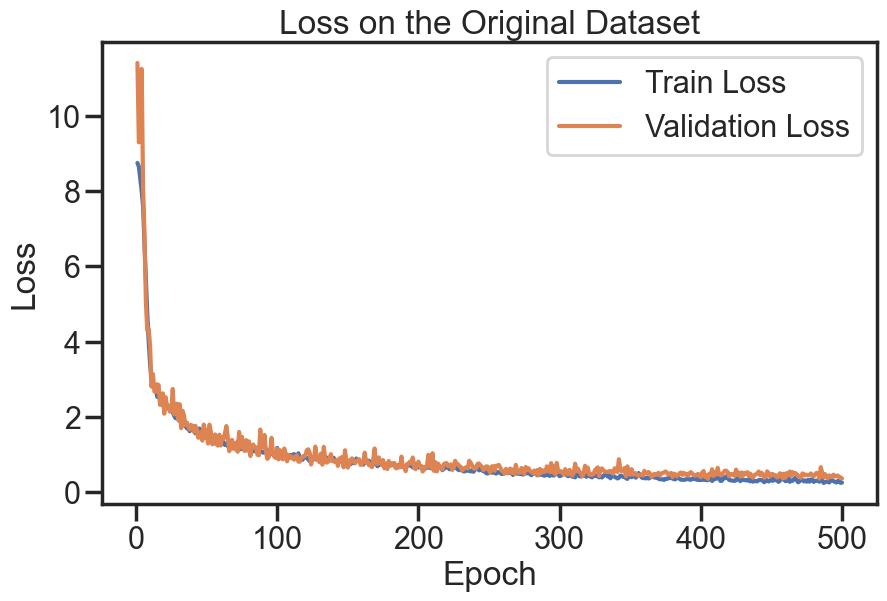

In [4]:
# 使用正则表达式提取Epoch、Train Loss和Validation Loss数据
epochs = []
train_losses = []
validation_losses = []

pattern = r"Epoch (\d+)/\d+, Train Loss: ([\d\.]+), Validation Loss: ([\d\.]+)"
matches = re.findall(pattern, log_text)

for match in matches:
    epoch, train_loss, val_loss = match
    epochs.append(int(epoch))
    train_losses.append(float(train_loss))
    validation_losses.append(float(val_loss))

# 将数据存储到DataFrame中
data = pd.DataFrame({
    'Epoch': epochs,
    'Train Loss': train_losses,
    'Validation Loss': validation_losses
})

# 使用Seaborn绘图
sns.set(style="ticks")
sns.set_context('poster')
plt.figure(figsize=(10, 6))

# 绘制训练损失和验证损失
sns.lineplot(x='Epoch', y='Train Loss', data=data, label='Train Loss')
sns.lineplot(x='Epoch', y='Validation Loss', data=data, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss on the Original Dataset')
plt.legend()
plt.show()

In [5]:
# 输入日志内容
log_text = """
Epoch 1/40, Train Loss: 2.7528, Validation Loss: 0.7914
Test Loss: 1.011982
Model saved!
Epoch 2/40, Train Loss: 0.6956, Validation Loss: 0.7237
Test Loss: 1.494957
Model saved!
Epoch 3/40, Train Loss: 0.5413, Validation Loss: 0.4315
Test Loss: 0.256355
Model saved!
Model saved!
Epoch 4/40, Train Loss: 0.4163, Validation Loss: 0.3440
Test Loss: 0.308391
Model saved!
Epoch 5/40, Train Loss: 0.3253, Validation Loss: 0.2587
Test Loss: 0.287654
Model saved!
Epoch 6/40, Train Loss: 0.2630, Validation Loss: 0.2107
Test Loss: 0.392354
Model saved!
Epoch 7/40, Train Loss: 0.2502, Validation Loss: 0.2919
Test Loss: 0.497543
Epoch 8/40, Train Loss: 0.2323, Validation Loss: 0.2193
Test Loss: 0.494273
Epoch 9/40, Train Loss: 0.2240, Validation Loss: 0.1836
Test Loss: 0.277500
Model saved!
Epoch 10/40, Train Loss: 0.1953, Validation Loss: 0.1555
Test Loss: 0.278496
Model saved!
Epoch 11/40, Train Loss: 0.1900, Validation Loss: 0.1723
Test Loss: 0.346614
Epoch 12/40, Train Loss: 0.1822, Validation Loss: 0.1517
Test Loss: 0.307856
Model saved!
Epoch 13/40, Train Loss: 0.1681, Validation Loss: 0.1427
Test Loss: 0.200045
Model saved!
Model saved!
Epoch 14/40, Train Loss: 0.1679, Validation Loss: 0.1351
Test Loss: 0.277778
Model saved!
Epoch 15/40, Train Loss: 0.1594, Validation Loss: 0.1199
Test Loss: 0.136127
Model saved!
Model saved!
Epoch 16/40, Train Loss: 0.1548, Validation Loss: 0.1162
Test Loss: 0.128460
Model saved!
Model saved!
Epoch 17/40, Train Loss: 0.1485, Validation Loss: 0.1310
Test Loss: 0.294029
Epoch 18/40, Train Loss: 0.1540, Validation Loss: 0.1425
Test Loss: 0.187452
Epoch 19/40, Train Loss: 0.1460, Validation Loss: 0.1192
Test Loss: 0.041104
Model saved!
Epoch 20/40, Train Loss: 0.1437, Validation Loss: 0.1314
Test Loss: 0.124227
Epoch 21/40, Train Loss: 0.1463, Validation Loss: 0.1196
Test Loss: 0.062527
Epoch 22/40, Train Loss: 0.1357, Validation Loss: 0.1520
Test Loss: 0.095061
Epoch 23/40, Train Loss: 0.1334, Validation Loss: 0.1707
Test Loss: 0.172189
Epoch 24/40, Train Loss: 0.1458, Validation Loss: 0.1542
Test Loss: 0.044694
Epoch 25/40, Train Loss: 0.1352, Validation Loss: 0.1115
Test Loss: 0.049218
Model saved!
Epoch 26/40, Train Loss: 0.1472, Validation Loss: 0.1242
Test Loss: 0.127287
Epoch 27/40, Train Loss: 0.1255, Validation Loss: 0.1213
Test Loss: 0.070499
Epoch 28/40, Train Loss: 0.1388, Validation Loss: 0.1329
Test Loss: 0.070418
Epoch 29/40, Train Loss: 0.1275, Validation Loss: 0.1284
Test Loss: 0.071898
Epoch 30/40, Train Loss: 0.1324, Validation Loss: 0.1119
Test Loss: 0.207152
Epoch 31/40, Train Loss: 0.1256, Validation Loss: 0.1168
Test Loss: 0.149034
Epoch 32/40, Train Loss: 0.1280, Validation Loss: 0.1084
Test Loss: 0.131431
Model saved!
Epoch 33/40, Train Loss: 0.1233, Validation Loss: 0.1060
Test Loss: 0.158477
Model saved!
Epoch 34/40, Train Loss: 0.1218, Validation Loss: 0.1065
Test Loss: 0.177651
Epoch 35/40, Train Loss: 0.1207, Validation Loss: 0.1229
Test Loss: 0.138489
Epoch 36/40, Train Loss: 0.1187, Validation Loss: 0.1079
Test Loss: 0.201269
Epoch 37/40, Train Loss: 0.1197, Validation Loss: 0.1002
Test Loss: 0.162996
Model saved!
Epoch 38/40, Train Loss: 0.1163, Validation Loss: 0.1125
Test Loss: 0.231992
Epoch 39/40, Train Loss: 0.1131, Validation Loss: 0.1276
Test Loss: 0.158915
Epoch 40/40, Train Loss: 0.1187, Validation Loss: 0.1065
Test Loss: 0.118594
"""

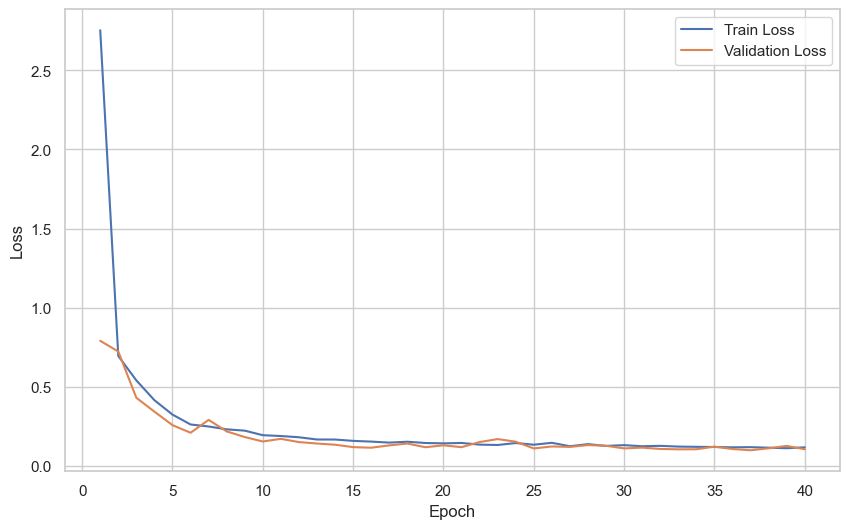

In [6]:
# 使用正则表达式提取Epoch、Train Loss和Validation Loss数据
epochs = []
train_losses = []
validation_losses = []

pattern = r"Epoch (\d+)/\d+, Train Loss: ([\d\.]+), Validation Loss: ([\d\.]+)"
matches = re.findall(pattern, log_text)

for match in matches:
    epoch, train_loss, val_loss = match
    epochs.append(int(epoch))
    train_losses.append(float(train_loss))
    validation_losses.append(float(val_loss))

# 将数据存储到DataFrame中
data = pd.DataFrame({
    'Epoch': epochs,
    'Train Loss': train_losses,
    'Validation Loss': validation_losses
})

# 使用Seaborn绘图
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# 绘制训练损失和验证损失
sns.lineplot(x='Epoch', y='Train Loss', data=data, label='Train Loss')
sns.lineplot(x='Epoch', y='Validation Loss', data=data, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
# plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

In [7]:
# 输入日志内容
log_text = """
Epoch 1/40, Train Loss: 0.1970, Validation Loss: 0.0370
Test Loss: 0.368544
Epoch 2/40, Train Loss: 0.0356, Validation Loss: 0.0338
Test Loss: 0.244563
Epoch 3/40, Train Loss: 0.0269, Validation Loss: 0.0291
Test Loss: 0.232411
Epoch 4/40, Train Loss: 0.0227, Validation Loss: 0.0203
Test Loss: 0.312309
Epoch 5/40, Train Loss: 0.0209, Validation Loss: 0.0194
Test Loss: 0.205820
Epoch 6/40, Train Loss: 0.0187, Validation Loss: 0.0188
Test Loss: 0.259585
Epoch 7/40, Train Loss: 0.0177, Validation Loss: 0.0173
Test Loss: 0.193088
Epoch 8/40, Train Loss: 0.0166, Validation Loss: 0.0187
Test Loss: 0.251619
Epoch 9/40, Train Loss: 0.0160, Validation Loss: 0.0162
Test Loss: 0.169496
Epoch 10/40, Train Loss: 0.0155, Validation Loss: 0.0183
Test Loss: 0.209574
Epoch 11/40, Train Loss: 0.0149, Validation Loss: 0.0134
Test Loss: 0.242536
Epoch 12/40, Train Loss: 0.0140, Validation Loss: 0.0140
Test Loss: 0.173226
Epoch 13/40, Train Loss: 0.0135, Validation Loss: 0.0169
Test Loss: 0.218139
Epoch 14/40, Train Loss: 0.0134, Validation Loss: 0.0149
Test Loss: 0.252599
Epoch 15/40, Train Loss: 0.0130, Validation Loss: 0.0135
Test Loss: 0.178019
Epoch 16/40, Train Loss: 0.0125, Validation Loss: 0.0152
Test Loss: 0.176996
Epoch 17/40, Train Loss: 0.0122, Validation Loss: 0.0121
Test Loss: 0.150896
Epoch 18/40, Train Loss: 0.0124, Validation Loss: 0.0117
Test Loss: 0.150414
Epoch 19/40, Train Loss: 0.0118, Validation Loss: 0.0109
Test Loss: 0.159639
Epoch 20/40, Train Loss: 0.0117, Validation Loss: 0.0102
Test Loss: 0.109334
Epoch 21/40, Train Loss: 0.0115, Validation Loss: 0.0102
Test Loss: 0.106861
Epoch 22/40, Train Loss: 0.0116, Validation Loss: 0.0108
Test Loss: 0.111011
Epoch 23/40, Train Loss: 0.0111, Validation Loss: 0.0103
Test Loss: 0.131996
Epoch 24/40, Train Loss: 0.0110, Validation Loss: 0.0096
Test Loss: 0.110544
Epoch 25/40, Train Loss: 0.0111, Validation Loss: 0.0121
Test Loss: 0.100870
Epoch 26/40, Train Loss: 0.0108, Validation Loss: 0.0130
Test Loss: 0.116860
Epoch 27/40, Train Loss: 0.0107, Validation Loss: 0.0113
Test Loss: 0.104136
Epoch 28/40, Train Loss: 0.0105, Validation Loss: 0.0127
Test Loss: 0.097375
Epoch 29/40, Train Loss: 0.0102, Validation Loss: 0.0094
Test Loss: 0.114744
Epoch 30/40, Train Loss: 0.0103, Validation Loss: 0.0157
Test Loss: 0.082491
Epoch 31/40, Train Loss: 0.0100, Validation Loss: 0.0092
Test Loss: 0.116967
Epoch 32/40, Train Loss: 0.0100, Validation Loss: 0.0115
Test Loss: 0.097304
Epoch 33/40, Train Loss: 0.0100, Validation Loss: 0.0098
Test Loss: 0.085950
Epoch 34/40, Train Loss: 0.0098, Validation Loss: 0.0104
Test Loss: 0.109362
Epoch 35/40, Train Loss: 0.0101, Validation Loss: 0.0092
Test Loss: 0.092018
Epoch 36/40, Train Loss: 0.0098, Validation Loss: 0.0093
Test Loss: 0.093155
Epoch 37/40, Train Loss: 0.0097, Validation Loss: 0.0091
Test Loss: 0.100468
Epoch 38/40, Train Loss: 0.0096, Validation Loss: 0.0096
Test Loss: 0.064105
Epoch 39/40, Train Loss: 0.0100, Validation Loss: 0.0109
Test Loss: 0.061167
Epoch 40/40, Train Loss: 0.0097, Validation Loss: 0.0089
Test Loss: 0.061757
"""

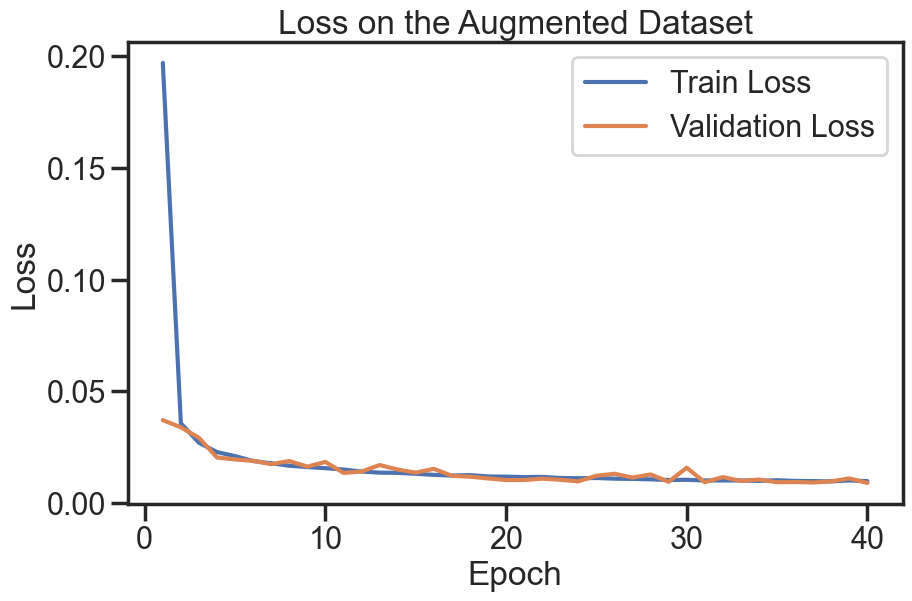

In [8]:

# 使用正则表达式提取Epoch、Train Loss和Validation Loss数据
epochs = []
train_losses = []
validation_losses = []

pattern = r"Epoch (\d+)/\d+, Train Loss: ([\d\.]+), Validation Loss: ([\d\.]+)"
matches = re.findall(pattern, log_text)

for match in matches:
    epoch, train_loss, val_loss = match
    epochs.append(int(epoch))
    train_losses.append(float(train_loss))
    validation_losses.append(float(val_loss))

# 将数据存储到DataFrame中
data = pd.DataFrame({
    'Epoch': epochs,
    'Train Loss': train_losses,
    'Validation Loss': validation_losses
})

# 使用Seaborn绘图
sns.set(style="ticks")
sns.set_context('poster')
plt.figure(figsize=(10, 6))

# 绘制训练损失和验证损失
sns.lineplot(x='Epoch', y='Train Loss', data=data, label='Train Loss')
sns.lineplot(x='Epoch', y='Validation Loss', data=data, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss on the Augmented Dataset')
plt.legend()
plt.show()